In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], add_acsf=True)
df = qm9.load()
molecules = qm9.get_molecules()

2026-04-17 11:34:50.732 | INFO     | src.datasets:load:493 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-17 11:34:51.000 | INFO     | src.datasets:_sample_qm9_df:685 - QM9 sampling complete: strategy=stratified, requested_limit=5500, returned_rows=5500.
2026-04-17 11:34:51.000 | INFO     | src.datasets:_add_requested_descriptors:126 - Applying requested QM9 descriptors to sampled dataframe (rows=5500).
2026-04-17 11:34:51.000 | INFO     | src.features:compute_acsf:201 - Computing ACSF (rcut=6.0)...
2026-04-17 11:35:27.854 | SUCCESS  | src.datasets:add_acsf:850 - Added ACSF embeddings.
2026-04-17 11:35:27.855 | INFO     | src.datasets:_add_requested_descriptors:149 - Added descriptor column(s): ['acsf_embedding']
2026-04-17 11:35:27.862 | INFO     | src.datasets:_drop_rows_with_null_required_descriptors:578 - Dropped QM9 rows with null/empty descriptor vectors: dropped=23, remaining=5477, descriptor_cols=['acsf_embedding'].
2026-04-17 11:35:27.862 | IN

In [6]:
len(molecules[0:2])

2

In [7]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [9]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="acsf",
    dist_type="euclidean",
    force_calculate=True
)

2026-04-17 11:36:08.844 | INFO     | src.datasets:get_distance_matrix:1001 - Calculating distance matrix for acsf using euclidean distance.
2026-04-17 11:36:09.214 | SUCCESS  | src.distance:_compute_and_save:79 - Saved distance matrix to data/QM9/dist_acsf_euclidean.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:06<00:00,  1.59it/s]


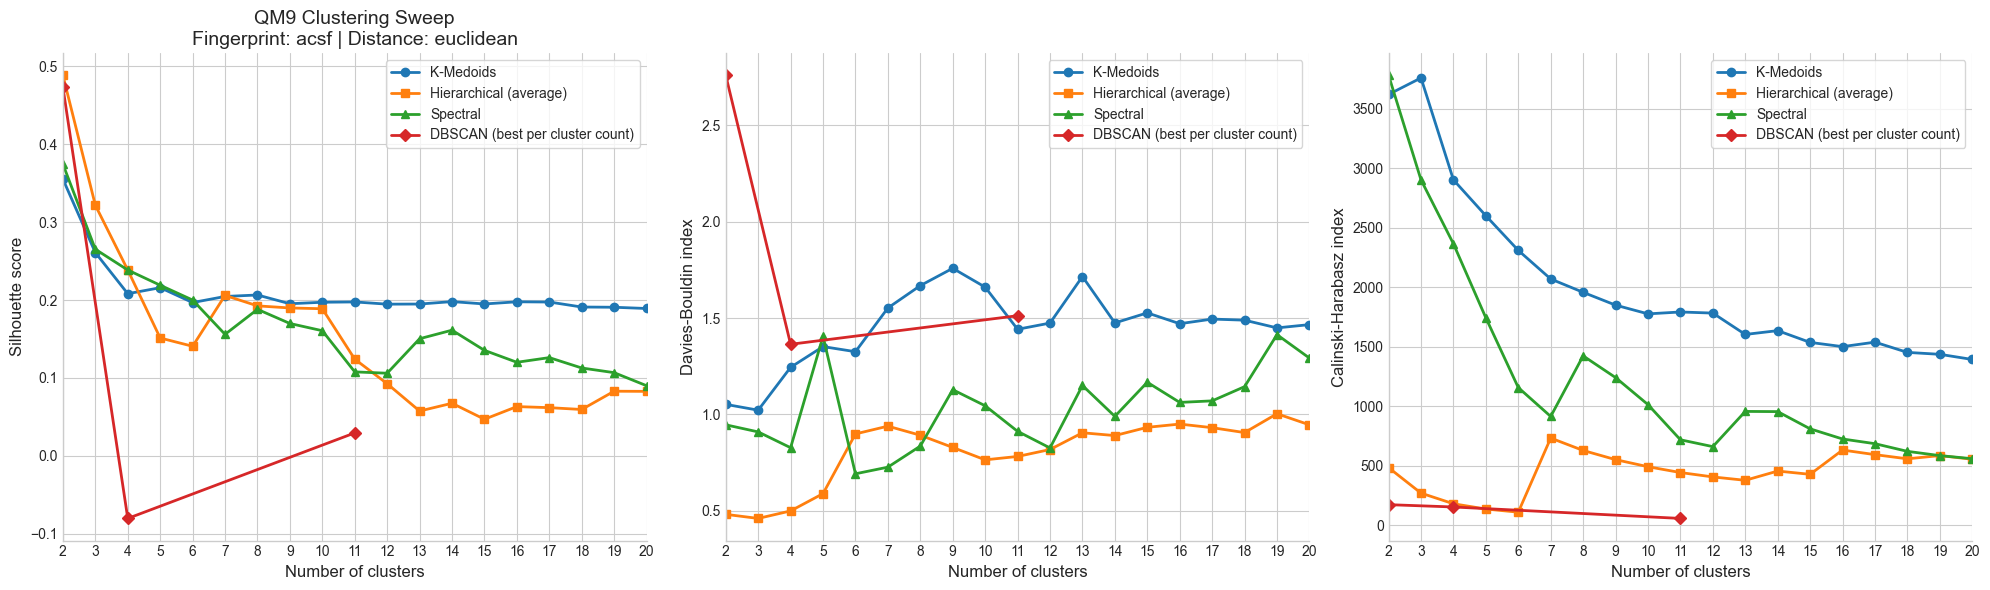

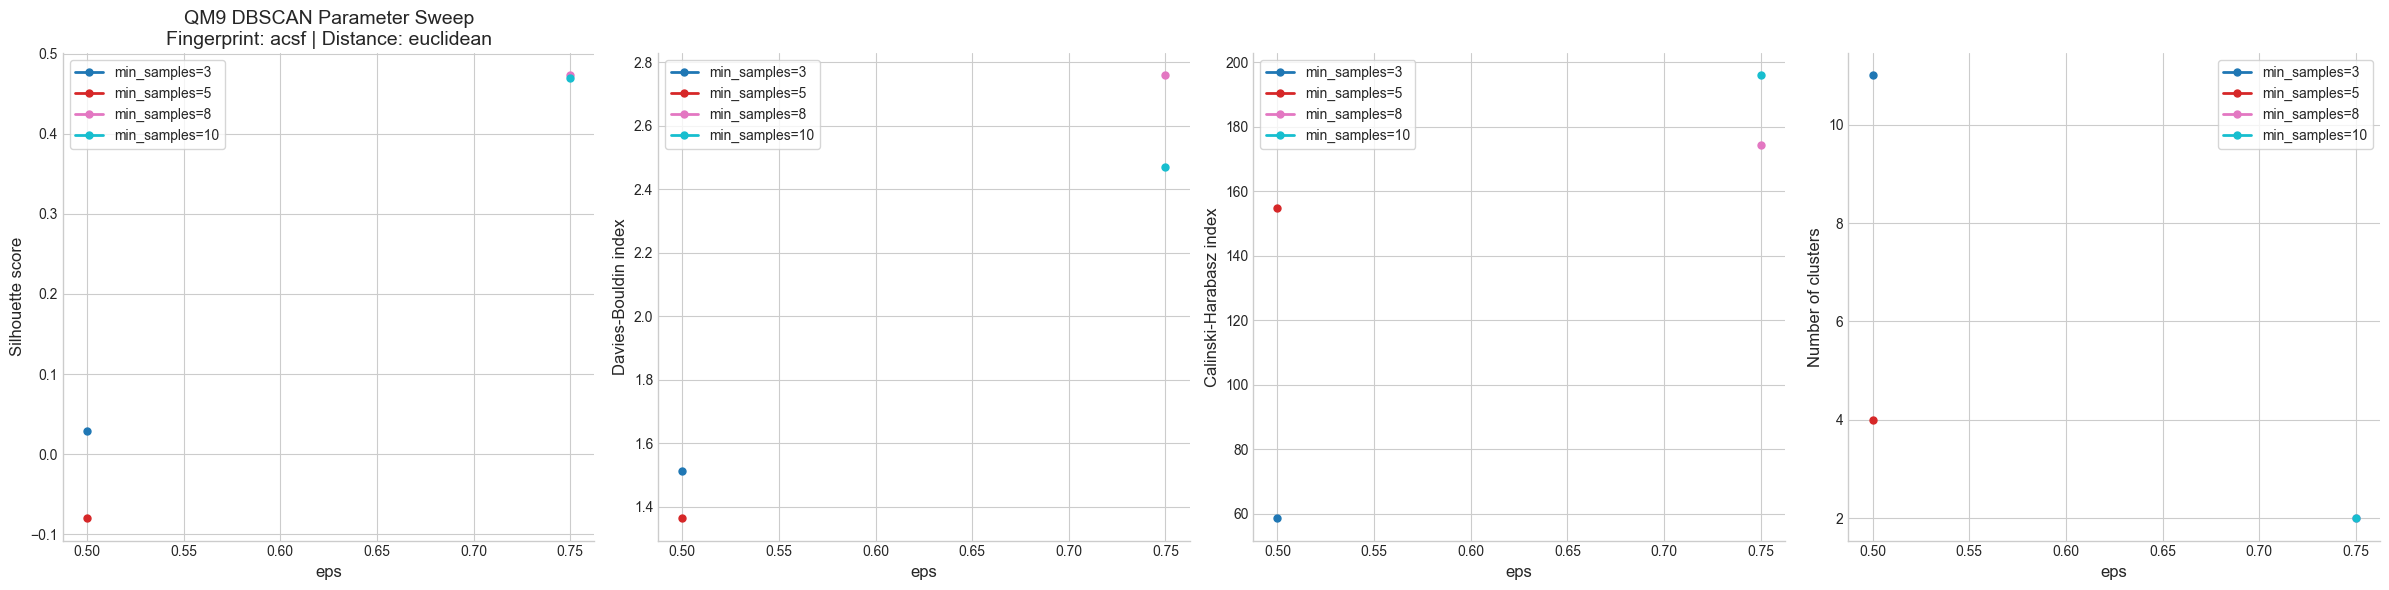

2026-04-17 11:37:08.371 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:840 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/acsf/clustering_sweep_2_to_20_clusters.png
2026-04-17 11:37:08.372 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:842 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/acsf/dbscan_parameter_sweep.png
2026-04-17 11:37:08.372 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:843 - Saved clustering sweep results to figures/qm9/clustering/euclidean/acsf/clustering_sweep_2_to_20_clusters.json


In [10]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    dataset_name="qm9",
)

In [11]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(1332), np.int64(1333)), (np.int64(1429), np.int64(1430)), (np.int64(3300), np.int64(3313)), (np.int64(4398), np.int64(4418)), (np.int64(2814), np.int64(2845)), (np.int64(3389), np.int64(3698)), (np.int64(3621), np.int64(3622)), (np.int64(3674), np.int64(3675)), (np.int64(4183), np.int64(4188)), (np.int64(1473), np.int64(1488))]


In [12]:
print(mols[0])

(Atoms(symbols='H3CH3NHOCNCNC2', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H3CH3NHOCNCNC2', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [14]:
plot_molecules_with_py3dmol(mols[1])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

In [13]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=3, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)

In [14]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [15]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-17 11:38:04.791 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_hierarchical_projection.png


{'coords': array([[-42.87330632,  26.97616543],
        [ 72.57577087,   0.38978408],
        [ 99.66756854,  32.53057816],
        ...,
        [-33.04061161,  41.09393408],
        [-45.10445665,  39.92296242],
        [-31.10718847, -25.59146542]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'hierarchical'}

In [16]:
average_numeric_by_cluster(df, "labels_hier")

shape: (3, 59)
┌─────────────┬───────┬─────────────────────┬───────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────────┬──────────────┬─────────────┐
│ labels_hier ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp    ┆ tpsa    ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆ num_ring

# KMedoids

In [17]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)

In [18]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [19]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-17 11:42:40.625 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_kmedoids_projection.png


{'coords': array([[-42.87330632,  26.97616543],
        [ 72.57577087,   0.38978408],
        [ 99.66756854,  32.53057816],
        ...,
        [-33.04061161,  41.09393408],
        [-45.10445665,  39.92296242],
        [-31.10718847, -25.59146542]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'kmedoids'}

In [20]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 60)
┌───────────┬───────┬─────────────────────┬───────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────────┬──────────────┬─────────────┐
│ labels_km ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp    ┆ tpsa    ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms 

# Spectral

In [26]:
model_spectral = SpectralClustering(
                n_clusters=4,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)
print(np.unique(labels_spectral, return_counts=True))

(array([0, 1, 2, 3], dtype=int32), array([4997,    1,    1,    1]))


In [27]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [22]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-17 11:53:09.149 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_spectral_projection.png


{'coords': array([[-42.87330632,  26.97616543],
        [ 72.57577087,   0.38978408],
        [ 99.66756854,  32.53057816],
        ...,
        [-33.04061161,  41.09393408],
        [-45.10445665,  39.92296242],
        [-31.10718847, -25.59146542]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'spectral'}

In [28]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (4, 61)
┌─────────────────┬───────┬─────────────────────┬───────────┬────────────┬────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬────────────────────┬──────────────┬─────────────┐
│ labels_spectral ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp   ┆ tpsa    ┆ election_affinity ┆ ionization_energ

# DBSCAN 

In [29]:
model_db = DBSCAN(
    eps=0.6,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), array([  30, 4927,    2,   15,    4,    2,    8,    3,    2,    3,    2,
          2]))


In [30]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [31]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-17 12:09:30.034 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_dbscan_projection.png


{'coords': array([[-42.87330632,  26.97616543],
        [ 72.57577087,   0.38978408],
        [ 99.66756854,  32.53057816],
        ...,
        [-33.04061161,  41.09393408],
        [-45.10445665,  39.92296242],
        [-31.10718847, -25.59146542]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'dbscan'}

In [32]:
average_numeric_by_cluster(df, "labels_db")

shape: (12, 62)
┌───────────┬───────┬─────────────────────┬───────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬─────────┬─────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬───────────┬───────────┬───────────┬──────────┬─────────┬────────┬────────┬─────────────┬───────────┬─────────────────┬────────────────────┬──────────────┬─────────────┐
│ labels_db ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp    ┆ tpsa    ┆ election_affinity ┆ io

# KMeans